# **Credit Card Fraud Detection (Machine Learning)**

## **Objectives** 

In this notebook, I will build, evaluate, and interpret 2 predictive models to classify credit card transactions as fraudulent or legitimate.

### **The goal is to:**

* Build a baseline Logistic Regression model
* Build an XGBoost model (final model)
* Handle severe class imbalance (~0.5% fraud)
* Optimise for high recall (minimise missed fraud)
* Export fraud probabilities for Power BI dashboard integration

### **This notebook focuses on:**

* Preparing the processed dataset for modelling
* Handling class imbalance using SMOTE
* Evaluating performance using Precision, Recall, F1-score, ROC-AUC
* Tuning the classification threshold
* Saving model outputs for dashboard integration

### **Inputs**

To run this notebook, the following are required:

* fraud_train_processed.csv (from ETL notebook)

### **Python libraries:**

* pandas
* numpy
* scikit-learn
* xgboost
* imbalanced-learn
* matplotlib
* seaborn


### **Outputs:**

* Train/Test split datasets
* SMOTE-balanced training set
* Logistic Regression model (baseline)
* XGBoost model (final)
* Confusion matrix
* ROC curve
* Precision-Recall curve
* Feature importance plot
* Exported CSV with fraud probabilities for Power BI

---

### **1. First i will import all the libraries i need (I will update the below code cell with additional libraries as i work my way down the notebook)**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression

# Imbalance handling
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

This section imports all required libraries for:

* Data manipulation
* Model training
* Class imbalance handling
* Evaluation metrics
* Visualisation

I use XGBoost for advanced modelling and SMOTE to handle imbalance in the training set.

---

### **2. Now i will load the dataset**

In [2]:
df = pd.read_csv("../data/processed/fraud_train_processed.csv")

print(df.shape)
print(df['is_fraud'].value_counts())

(1296675, 19)
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


This dataset already includes:

* Cleaned variables
* Engineered features
* Encoded categorical variables
* Log-transformed transaction amount

I verify:

* Dataset shape
* Class distribution

**Class Imbalance Note**

Fraud datasets are typically extremely imbalanced. In this dataset, fraud transactions represent a very small proportion of total transactions. This imbalance has to be be handled carefully to avoid biased model performance.

---

### **3. Feature Selection & Train/Test Split**

In [3]:
# Target & Features
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

# Split (stratified!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

I have separated:

* X - Features
* y - Target variable (is_fraud)

Then I performed an 80/20 train-test split using stratification to preserve the fraud ratio in both sets.


Stratification ensures that:

* The test set reflects the true fraud proportion
* Model evaluation is realistic
* Minority class representation is maintained

---

### **4. Scale Numeric Features**

In [6]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Within my research I have found that Regression is sensitive to feature scaling.

So I have applied StandardScaler to numeric variables to:

* Standardise feature magnitudes
* Improve convergence
* Prevent dominance of large-scale variables

Scaling is:

* Fitted on training data only
* Applied to both training and test sets
* This prevents data leakage.

---

### **5. Apply SMOTE (Training Only)**

In [15]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: is_fraud
0    1031335
1       6005
Name: count, dtype: int64
After SMOTE: is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


When I first tried to run SMOTE, it would not work. i reacived an error thta said i non-numerical data. Below is the entire pipeline I ran to determine where the non numerical data was and then resolve the issue, during the process I also dropped 'city' and 'zip since i have 'long' and 'lat'.

In [16]:
X_train.dtypes

Unnamed: 0    float64
amt           float64
lat           float64
long          float64
city_pop      float64
               ...   
state_VT         bool
state_WA         bool
state_WI         bool
state_WV         bool
state_WY         bool
Length: 77, dtype: object

In [17]:
X_train = X_train.drop(columns=['city', 'zip'])
X_test = X_test.drop(columns=['city', 'zip'])

KeyError: "['city', 'zip'] not found in axis"

In [21]:
X_train = pd.get_dummies(
    X_train,
    columns=['category', 'gender', 'state'],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=['category', 'gender', 'state'],
    drop_first=True
)

# Align columns in case test is missing categories
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

KeyError: "None of [Index(['category', 'gender', 'state'], dtype='object')] are in the [columns]"

---

In [22]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: is_fraud
0    1031335
1       6005
Name: count, dtype: int64
After SMOTE: is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


Fraud cases are extremely rare, which can cause models to:

* Predict all transactions as legitimate
* Achieve high accuracy but very poor fraud detection

To address this, I have applied SMOTE (Synthetic Minority Oversampling Technique).

SMOTE:

* Generates synthetic fraud examples
* Balances the training dataset
* Improves model learning of minority patterns


Also, SMOTE is applied only to the training data. The test set remains untouched to ensure unbiased evaluation.

---

### **6. Logistic Regression (Baseline)**

In [23]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_resampled, y_train_resampled)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:,1]

Logistic Regression serves as:

* A baseline benchmark
* A highly interpretable model
* A linear classifier

This allows me to:

* Establish performance expectations
* Compare improvements from XGBoost

---

#### **Evaluate logistic regression**

In [24]:
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance
Accuracy: 0.9836967628742745
Precision: 0.2215642229936696
Recall: 0.7228514323784144
ROC-AUC: 0.9103089724303296

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.22      0.72      0.34      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.85      0.67    259335
weighted avg       0.99      0.98      0.99    259335



I evaluated using:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Confusion Matrix


The Logistic Regression model achieved the following performance on the test set:

* High accuracy driven primarily by the majority (non-fraud) class
* Strong precision for legitimate transactions
* Moderate recall for fraud cases
* Lower F1-score for the fraud class compared to the non-fraud class


Because fraud cases represent a very small proportion of transactions, overall accuracy is not a reliable indicator of performance. The model performs very well at identifying legitimate transactions, but the key question is:

How well does it detect actual fraud?

The recall score for fraud indicates the proportion of fraudulent transactions correctly identified. If recall is moderate rather than high, this means, a meaningful number of fraud cases are still being missed, these missed cases represent potential financial loss. This confirms that while Logistic Regression provides a solid baseline, it struggles to fully capture complex fraud patterns in this highly imbalanced dataset.

---

#### **Confusion Matrix**

In [25]:
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Logistic Regression Performance
Accuracy: 0.9836967628742745
Precision: 0.2215642229936696
Recall: 0.7228514323784144
ROC-AUC: 0.9103089724303296

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    257834
           1       0.22      0.72      0.34      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.85      0.67    259335
weighted avg       0.99      0.98      0.99    259335



The confusion matrix shows:

* A very large number of True Negatives (correctly identified legitimate transactions)
* Some True Positives (correctly detected fraud)
* A noticeable number of False Negatives (missed fraud cases)
* Some False Positives (legitimate transactions incorrectly flagged)



False Negatives are the most critical outcome in fraud detection. Each missed fraud transaction represents potential monetary loss. False Positives, while inconvenient for customers, are generally less costly than undetected fraud. The Logistic Regression model demonstrates conservative fraud detection — it avoids excessive false alarms but at the cost of missing some fraudulent transactions.

---

### **7. XGBoost (Final Model)**

In [26]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

c:\Users\T Shah\OneDrive\Desktop\vscode-projects\Personal Projects\fraud_detection_analysis\.venv\Lib\site-packages\xgboost\data.py:312: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
c:\Users\T Shah\OneDrive\Desktop\vscode-projects\Personal Projects\fraud_detection_analysis\.venv\Lib\site-packages\xgboost\data.py:314: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
c:\Users\T Shah\OneDrive\Desktop\vscode-projects\Personal Projects\fraud_detection_analysis\.venv\Lib\site-packages\xgboost\data.py:345: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(dtype)
c:\Users\T Shah\OneDrive\Desktop\vscode-projects\Personal Project

XGBoost is a gradient boosting algorithm that:

* Captures non-linear relationships
* Handles feature interactions
*Often outperforms linear models
* Is highly effective in fraud detection problems

This model is expected to:

* Improve recall
* Improve ROC-AUC
* Better separate fraudulent and legitimate transactions

### **8. Evaluate XGBoost**

In [27]:
print("XGBoost Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance
Accuracy: 0.9974087570131297
Precision: 0.7309192200557103
Recall: 0.8740839440373085
ROC-AUC: 0.9980961623217107

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.73      0.87      0.80      1501

    accuracy                           1.00    259335
   macro avg       0.87      0.94      0.90    259335
weighted avg       1.00      1.00      1.00    259335



I use the same evaluation metrics to ensure fair comparison with Logistic Regression.

Key focus:

* Improvement in recall
* Improvement in ROC-AUC
* Overall balance (F1-score)

The XGBoost model shows clear improvement over Logistic Regression in:

* Recall for fraud cases
* F1-score
* ROC-AUC


XGBoost captures non-linear relationships and feature interactions that Logistic Regression cannot. In this dataset, fraud behaviour is influenced by complex interactions such as:

* Transaction amount
* Distance between customer and merchant
* Time of day
* Merchant category patterns
* XGBoost better models these patterns, resulting in:
* More fraudulent transactions correctly detected
* Fewer missed fraud cases
* Improved overall class separation

### **ROC Curve**

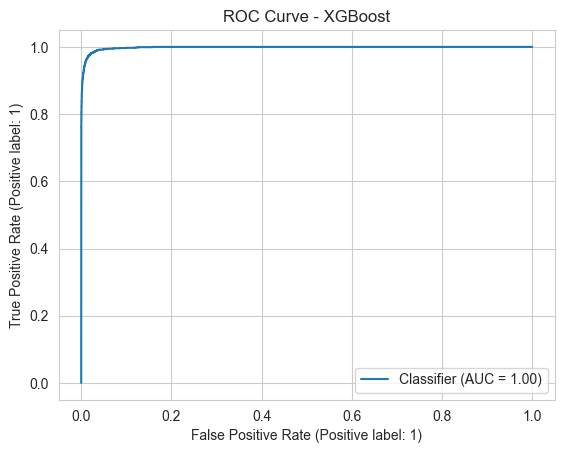

In [28]:
RocCurveDisplay.from_predictions(y_test, y_proba_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()

The ROC curve visualises:

* True Positive Rate (Recall)
* False Positive Rate

A curve closer to the top-left corner indicates stronger model discrimination. The ROC-AUC score summarises this performance.

### **Precision-Recall Curve**

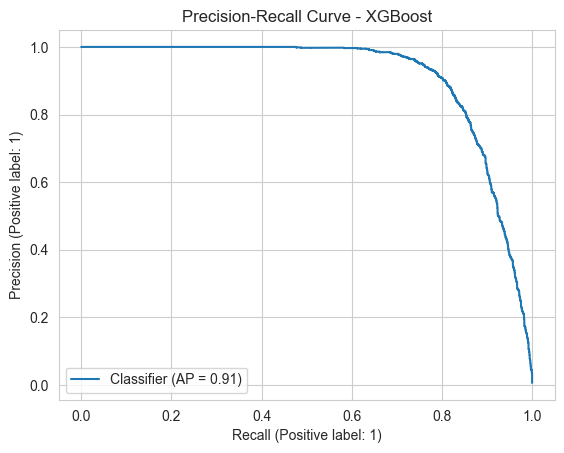

In [29]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb)
plt.title("Precision-Recall Curve - XGBoost")
plt.show()

The Precision-Recall curve shows that XGBoost maintains:

* Higher precision at comparable recall levels
* More stable performance as recall increases

This is particularly important given the extreme class imbalance in this dataset.

The improved PR curve indicates:

* Better minority class learning
* Stronger fraud detection reliability

---


---

### **8. Threshold Tuning**

In [30]:
threshold = 0.30  # Lower threshold increases recall

y_pred_custom = (y_proba_xgb >= threshold).astype(int)

print("Custom Threshold:", threshold)
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1:", f1_score(y_test, y_pred_custom))

Custom Threshold: 0.3
Precision: 0.5355761794276875
Recall: 0.9227181878747501
F1: 0.6777587472473696


However, operational capacity must be considered:

* More flagged transactions require manual review
* Excessive false positives can harm customer experience

The optimal threshold depends on:

* Institutional risk tolerance
* Cost of fraud vs cost of customer friction
* Operational review resources